In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
words = open('names.txt','r').read().splitlines()

In [3]:
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
# build vocabulary mapping
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

vocab_size = len(itos)
block_size = 3
print(itos)
print(vocab_size)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [6]:
# build the dataset
import torch
import random

def build_dataset(words):
    block_size = 3  # context length: how many characters do we take to predict the next one?
    X, Y = [], []

    for w in words:
        # initialize context with zeros
        context = [0] * block_size

        # iterate over characters in the word, plus end token '.'
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)

            # crop and append
            context = context[1:] + [ix]

    # convert to tensors
    X = torch.tensor(X, dtype=torch.int64)
    Y = torch.tensor(Y, dtype=torch.int64)

    print(X.shape, Y.shape)
    return X, Y


# ---------------------------
# train / dev / test split
# ---------------------------
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
# MLP revisit
n_embd = 10 # dimiension of embeddings
n_hidden = 200 # number of the neurons in hidden layer

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) /((n_embd * block_size) ** 0.5) # 0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden,vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True


12297


In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator = g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden lay pre-activation
    # batch normalization
    bnmeani =hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani )/ bnstdi + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update parameters
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track
    if i % 10000 == 0:
        print(f'{i: 7d}/{max_steps:7d} : {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/ 200000 : 3.3147
  10000/ 200000 : 2.1984
  20000/ 200000 : 2.2950
  30000/ 200000 : 2.3937
  40000/ 200000 : 1.9780
  50000/ 200000 : 2.4495
  60000/ 200000 : 2.4431
  70000/ 200000 : 2.0071
  80000/ 200000 : 2.2948
  90000/ 200000 : 2.1144
 100000/ 200000 : 2.0097
 110000/ 200000 : 2.3772
 120000/ 200000 : 2.0301


(array([170., 206., 172., 144., 166., 133., 149., 126., 127., 121., 106.,
        109., 129.,  94., 128., 103., 109.,  86., 112.,  83., 100.,  75.,
         99.,  88.,  87., 112.,  83., 130., 115.,  95., 108., 106., 118.,
         94.,  99., 126.,  85., 126., 124., 113., 122., 120., 143., 158.,
        165., 192., 182., 176., 257., 229.]),
 array([-9.99114394e-01, -9.59151689e-01, -9.19188983e-01, -8.79226278e-01,
        -8.39263573e-01, -7.99300867e-01, -7.59338162e-01, -7.19375457e-01,
        -6.79412751e-01, -6.39450046e-01, -5.99487340e-01, -5.59524635e-01,
        -5.19561930e-01, -4.79599224e-01, -4.39636519e-01, -3.99673814e-01,
        -3.59711108e-01, -3.19748403e-01, -2.79785697e-01, -2.39822992e-01,
        -1.99860287e-01, -1.59897581e-01, -1.19934876e-01, -7.99721706e-02,
        -4.00094652e-02, -4.67598438e-05,  3.99159455e-02,  7.98786509e-02,
         1.19841356e-01,  1.59804062e-01,  1.99766767e-01,  2.39729472e-01,
         2.79692178e-01,  3.19654883e-01,  3.59617

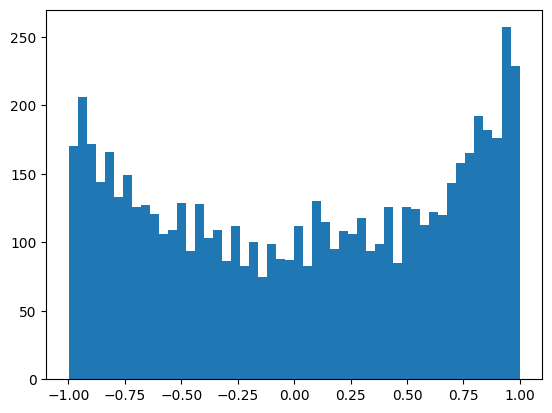

In [52]:
plt.hist(h.view(-1).tolist(), 50)

(array([  2.,   3.,   1.,   2.,   2.,   1.,   6.,   8.,  13.,  26.,  37.,
         35.,  57.,  90., 120., 112., 136., 205., 221., 257., 275., 321.,
        362., 351., 320., 404., 386., 358., 338., 303., 265., 272., 243.,
        192., 126., 133., 125.,  90.,  53.,  32.,  28.,  25.,  19.,  15.,
          9.,   6.,   2.,  10.,   2.,   1.]),
 array([-3.86098313, -3.70754832, -3.5541135 , -3.40067869, -3.24724387,
        -3.09380906, -2.94037424, -2.78693943, -2.63350461, -2.48006979,
        -2.32663498, -2.17320016, -2.01976535, -1.86633053, -1.71289572,
        -1.5594609 , -1.40602609, -1.25259127, -1.09915646, -0.94572164,
        -0.79228683, -0.63885201, -0.48541719, -0.33198238, -0.17854756,
        -0.02511275,  0.12832207,  0.28175688,  0.4351917 ,  0.58862651,
         0.74206133,  0.89549614,  1.04893096,  1.20236578,  1.35580059,
         1.50923541,  1.66267022,  1.81610504,  1.96953985,  2.12297467,
         2.27640948,  2.4298443 ,  2.58327911,  2.73671393,  2.89014874,
 

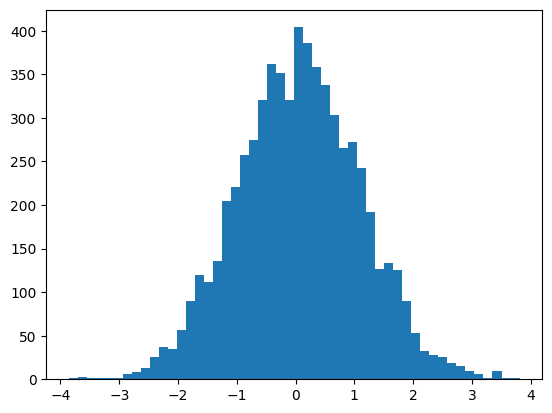

In [53]:
plt.hist(hpreact.view(-1).tolist(), 50)

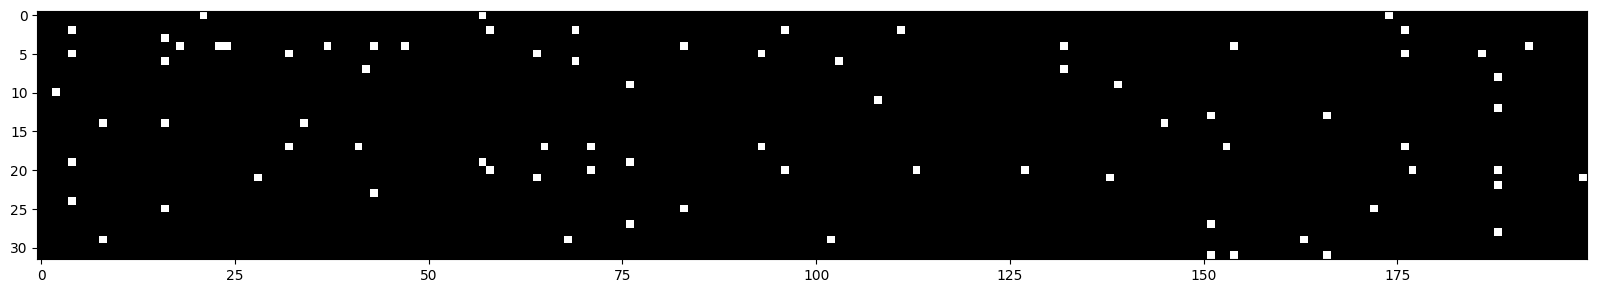

In [54]:
plt.figure(figsize = (20,10))
plt.imshow(h.abs() > 0.99, cmap='gray',interpolation = 'nearest')

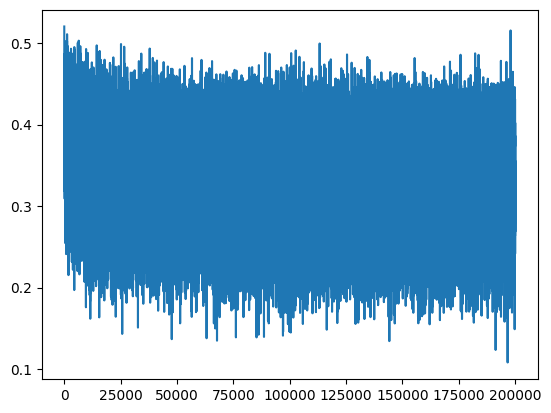

In [35]:
plt.plot(lossi)

In [70]:
# calibrate the batch norm at the end of training
with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1

    # measure the mean / std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [71]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val':   (Xdev, Ydev),
        'test':  (Xte, Yte),
    }[split]

    emb = C[x]                           # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)  # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True))/hpreact.std(0, keepdim=True) + bnbias
    hpreact = bngain * (hpreact - bnmean_running)/bnstd_running + bnbias
    h = torch.tanh(hpreact)     # (N, n_hidden)
    logits = h @ W2 + b2                 # (N, vocab_size)

    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


# evaluate splits
split_loss('train')
split_loss('val')

train 2.1110355854034424
val 2.1400630474090576


In [37]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size  # initialize with all ...

    while True:
        # forward pass through the neural net
        emb = C[torch.tensor([context])]        # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)

        # if we sample the special '.' token, break
        if ix == 0:
            break

    # decode and print the generated word
    print(''.join(itos[i] for i in out))

carla.
fatifil.
khi.
mili.
taty.
salayson.
mahnelfemdyric.
kaeli.
nermari.
chaiivan.
leigh.
ham.
join.
quinn.
sulin.
alianni.
warthogiearyni.
jameenicsa.
mel.
emi.


tensor(-0.0105) tensor(0.9888)
tensor(0.0021) tensor(1.0080)


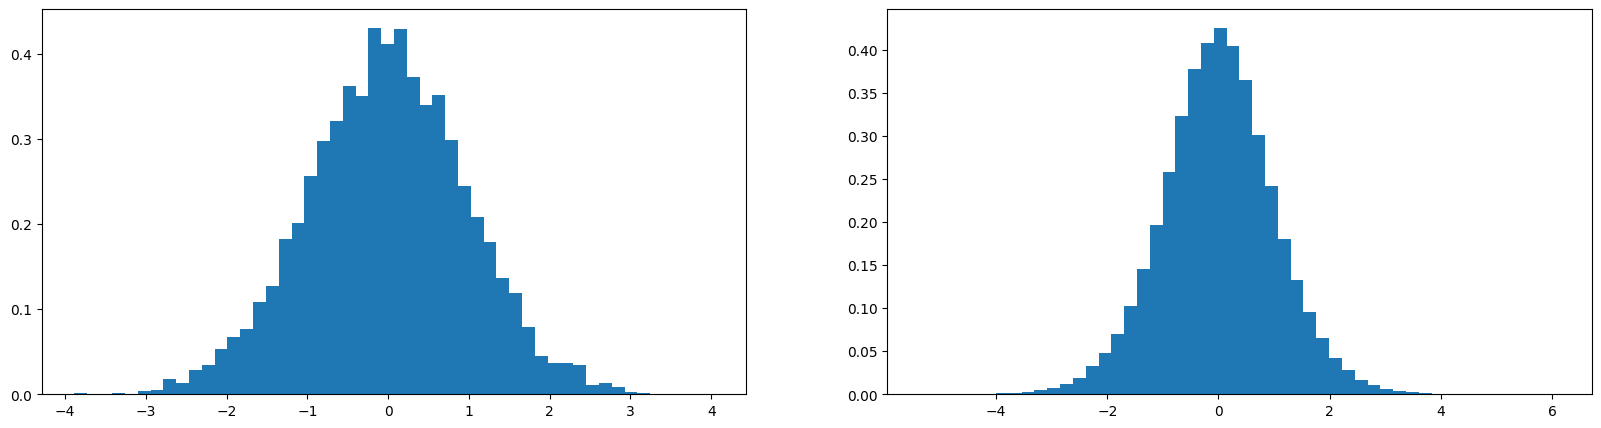

In [57]:
# generate data
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / (10 ** 0.5)
y = x @ w

# print statistics
print(x.mean(), x.std())
print(y.mean(), y.std())

# plot histograms
plt.figure(figsize=(20, 5))

plt.subplot(121)
plt.hist(x.view(-1).tolist(), bins=50, density=True)

plt.subplot(122)
plt.hist(y.view(-1).tolist(), bins=50, density=True)

plt.show()
